In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



In [4]:
#loading dataset
df = pd.read_csv('household_power_consumption.txt', sep=';', 
                 low_memory=False, na_values=['?'])

In [5]:
df.head(5)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [6]:
df.shape

(2075259, 9)

In [7]:
df.isnull().sum()

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [8]:
# A. Clean column names (removing hidden spaces)
df.columns = df.columns.str.strip()

In [9]:
new_data = df.ffill() #handle missing value using forward fill


In [10]:
new_data.isnull().sum()

Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

In [11]:
# . Convert to time-series format
# Combine Date and Time and set as index 
new_data['datetime'] = pd.to_datetime(new_data['Date'] + ' ' + new_data['Time'], 
                                     format='%d/%m/%Y %H:%M:%S')
new_data.set_index('datetime', inplace=True)
new_data.drop(['Date', 'Time'], axis=1, inplace=True)

In [12]:
# Check duplicate timestamps
duplicate_timestamps = new_data.index.duplicated().sum()
print("Duplicate timestamps:", duplicate_timestamps)


Duplicate timestamps: 0


In [13]:

#. Ensure all columns are numeric 
cols = ['Global_active_power', 'Global_reactive_power', 'Voltage', 
        'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
new_data[cols] = new_data[cols].apply(pd.to_numeric, errors='coerce')


In [14]:
# This smooths noise and makes computation manageable 
hourly_data = new_data.resample('H').mean()

/var/folders/fd/2_6wbxhs7ylbs803bysz1_700000gn/T/ipykernel_2904/1898340687.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_data = new_data.resample('H').mean()


In [15]:
# 1. Existing Time-based Features
hourly_data['hour'] = hourly_data.index.hour
hourly_data['day_of_week'] = hourly_data.index.dayofweek
hourly_data['month'] = hourly_data.index.month


# Is it a peak energy hour? (Typically 5 PM to 9 PM)
hourly_data['is_peak'] = hourly_data['hour'].apply(lambda x: 1 if 17 <= x <= 21 else 0)

# 2. ADD NEW LAG FEATURES (Memory)
hourly_data['lag_1h'] = hourly_data['Global_active_power'].shift(1)
hourly_data['lag_2h'] = hourly_data['Global_active_power'].shift(2)
hourly_data['lag_24h'] = hourly_data['Global_active_power'].shift(24)

# --- NEW: LAG DIFFERENCE (Is usage going up or down?) ---
# This helps the model see the "velocity" of energy consumption
hourly_data['diff_1h'] = hourly_data['lag_1h'] - hourly_data['lag_2h']

# 3. ADD ROLLING MEAN (Trend)
hourly_data['rolling_mean_6h'] = hourly_data['Global_active_power'].rolling(window=6).mean()



# 3. Weekly Lag (Comparing this hour to the same hour last week)
# 168 hours = 7 days. This is very powerful for weekend patterns!
hourly_data['lag_168h'] = hourly_data['Global_active_power'].shift(168)

# Comparing today to the same hour yesterday
hourly_data['daily_change'] = hourly_data['lag_1h'] - hourly_data['lag_24h']


# 1. Create a "Winter/High Demand" Switch
# Returns 1 for Nov, Dec, Jan, Feb; otherwise 0
hourly_data['is_high_season'] = hourly_data['month'].apply(lambda x: 1 if x in [11, 12, 1, 2] else 0)

# 2. Create a "Summer/Low Demand" Switch
# Returns 1 for Jul, Aug, Sep; otherwise 0
hourly_data['is_low_season'] = hourly_data['month'].apply(lambda x: 1 if x in [7, 8, 9] else 0)

# 4. Forward   and backward  Fill
hourly_data.fillna(method='ffill', inplace=True)


/var/folders/fd/2_6wbxhs7ylbs803bysz1_700000gn/T/ipykernel_2904/4014705480.py:44: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  hourly_data.fillna(method='ffill', inplace=True)


In [16]:
hourly_data.isnull().sum()

Global_active_power        0
Global_reactive_power      0
Voltage                    0
Global_intensity           0
Sub_metering_1             0
Sub_metering_2             0
Sub_metering_3             0
hour                       0
day_of_week                0
month                      0
is_peak                    0
lag_1h                     1
lag_2h                     2
lag_24h                   24
diff_1h                    2
rolling_mean_6h            5
lag_168h                 168
daily_change              24
is_high_season             0
is_low_season              0
dtype: int64

In [17]:
hourly_data=hourly_data.dropna()

In [18]:
hourly_data.isnull().sum()


Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
hour                     0
day_of_week              0
month                    0
is_peak                  0
lag_1h                   0
lag_2h                   0
lag_24h                  0
diff_1h                  0
rolling_mean_6h          0
lag_168h                 0
daily_change             0
is_high_season           0
is_low_season            0
dtype: int64

In [19]:
hourly_data.head(5)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day_of_week,month,is_peak,lag_1h,lag_2h,lag_24h,diff_1h,rolling_mean_6h,lag_168h,daily_change,is_high_season,is_low_season
datetime,,,,,,,,,,,,,,,,,,,,
2006-12-23 17:00:00,5.452533,0.215967,233.644167,23.360000,16.183333,0.666667,16.750000,17,5,12,1,4.349100,4.049100,1.496800,0.300000,3.990633,4.222889,2.852300,1,0
2006-12-23 18:00:00,3.879400,0.099767,238.000500,16.363333,0.000000,0.016667,17.350000,18,5,12,1,5.452533,4.349100,2.686967,1.103433,4.149067,3.632200,2.765567,1,0
2006-12-23 19:00:00,4.117833,0.205333,238.729333,17.300000,0.000000,0.600000,17.466667,19,5,12,1,3.879400,5.452533,3.938167,-1.573133,4.267656,3.400233,-0.058767,1,0
2006-12-23 20:00:00,4.181400,0.124767,238.518833,17.596667,0.000000,0.350000,17.416667,20,5,12,1,4.117833,3.879400,3.536067,0.238433,4.338228,3.268567,0.581767,1,0
2006-12-23 21:00:00,3.288433,0.235767,238.594667,13.893333,0.000000,0.216667,5.666667,21,5,12,1,4.181400,4.117833,4.548667,0.063567,4.211450,3.056467,-0.367267,1,0


In [20]:
# 3. EXPLORATORY DATA ANALYSIS

In [21]:
print("--- Dataset Summary Statistics ---")
print(hourly_data.describe())

--- Dataset Summary Statistics ---
       Global_active_power  Global_reactive_power       Voltage  \
count         34421.000000           34421.000000  34421.000000   
mean              1.082893               0.123340    240.840404   
std               0.892303               0.067229      2.997125   
min               0.124000               0.000000    225.834500   
25%               0.341100               0.077633    239.200167   
50%               0.795333               0.106800    240.982833   
75%               1.570600               0.149400    242.687667   
max               6.560533               0.774333    251.902000   

       Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  \
count      34421.000000    34421.000000    34421.000000    34421.000000   
mean           4.590422        1.112051        1.284094        6.407252   
std            3.734961        3.522093        4.159765        7.340743   
min            0.503333        0.000000        0.000000      

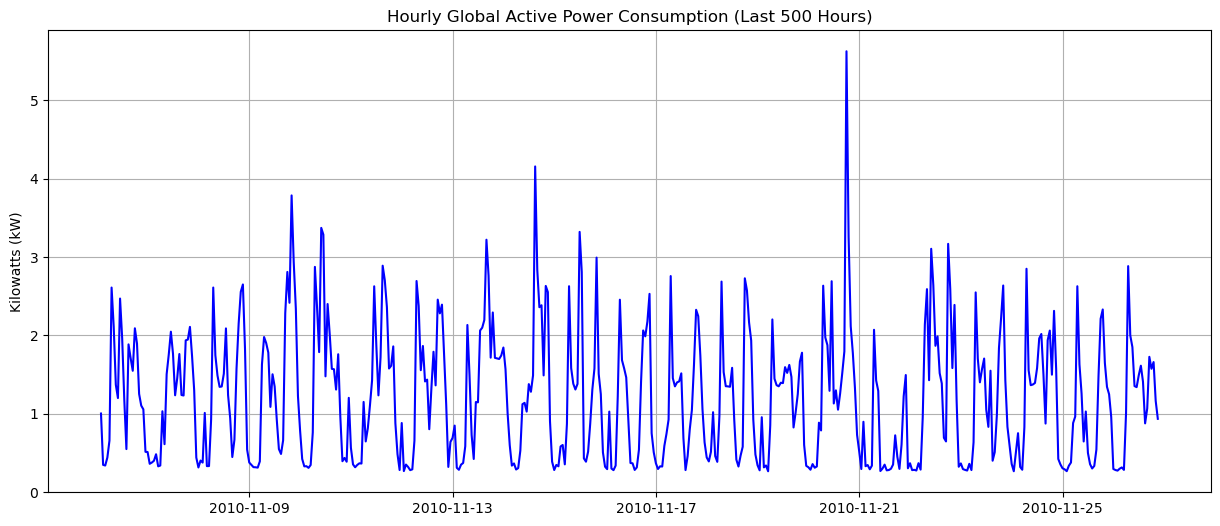

In [22]:
#Visualization: Line Plot of Energy Consumption
plt.figure(figsize=(15, 6))
plt.plot(hourly_data['Global_active_power'].tail(500), color='blue')
plt.title('Hourly Global Active Power Consumption (Last 500 Hours)')
plt.ylabel('Kilowatts (kW)')
plt.grid(True)
plt.show()

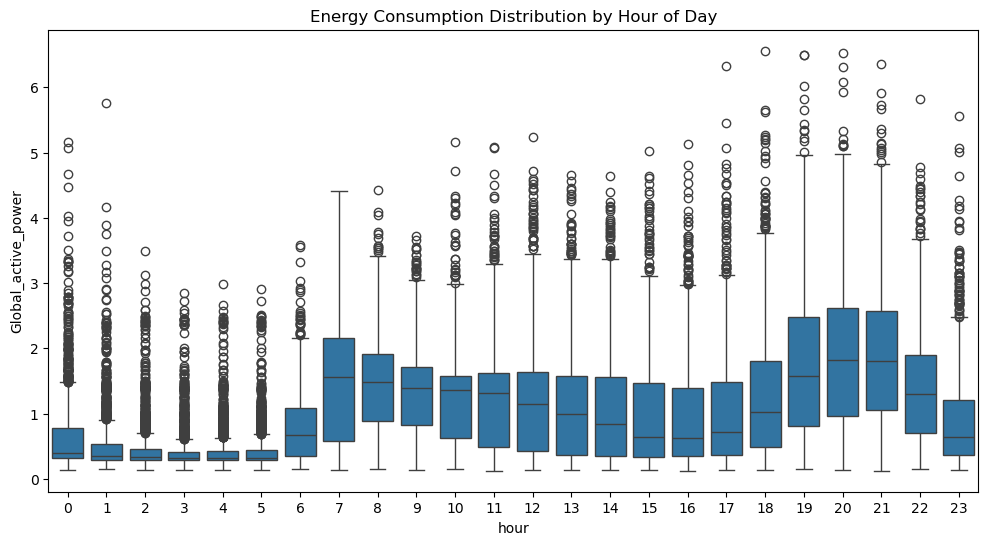

In [23]:
#Box Plot for Seasonality [cite: 61]
plt.figure(figsize=(12, 6))
sns.boxplot(x='hour', y='Global_active_power', data=hourly_data)
plt.title('Energy Consumption Distribution by Hour of Day')
plt.show()


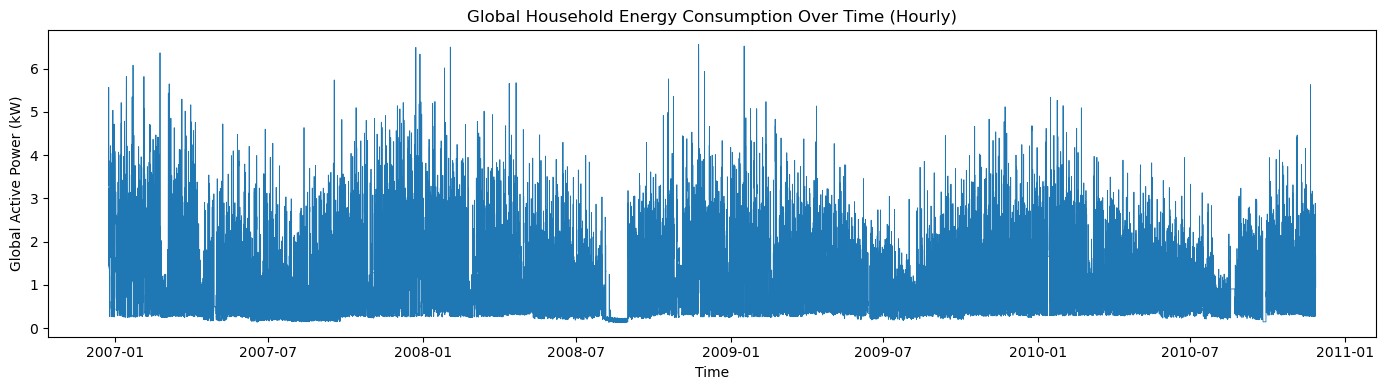

In [24]:
plt.figure(figsize=(14, 4))
plt.plot(hourly_data.index, hourly_data['Global_active_power'], linewidth=0.6)

plt.title("Global Household Energy Consumption Over Time (Hourly)")
plt.xlabel("Time")
plt.ylabel("Global Active Power (kW)")
plt.tight_layout()
plt.show()

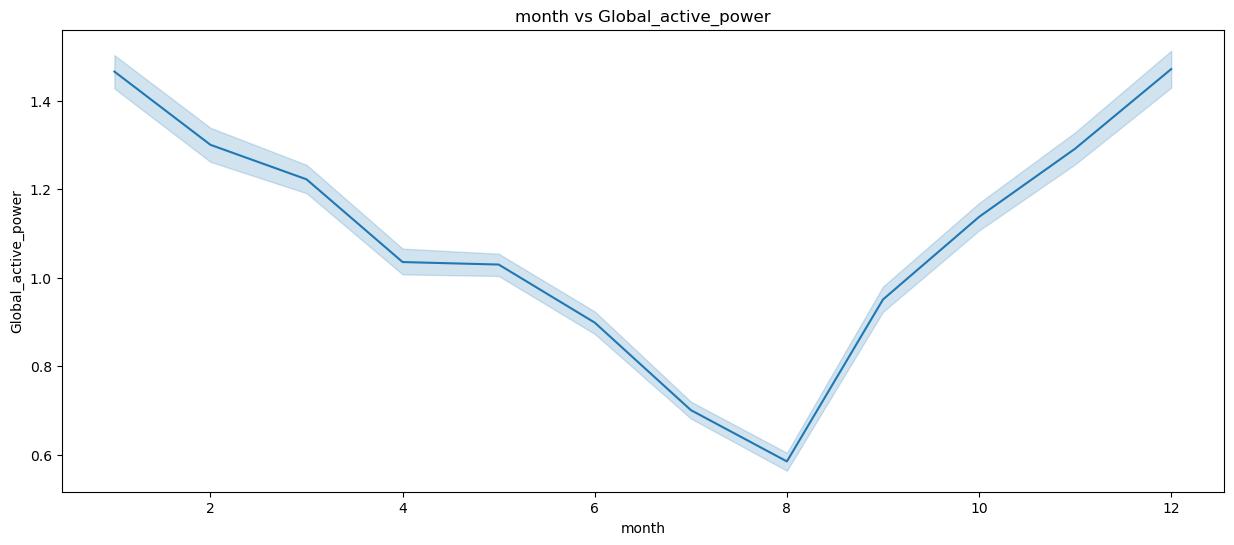

In [25]:
plt.figure(figsize=(15, 6))
sns.lineplot(x='month', y='Global_active_power', data=hourly_data)
plt.title('month vs Global_active_power')
plt.show()

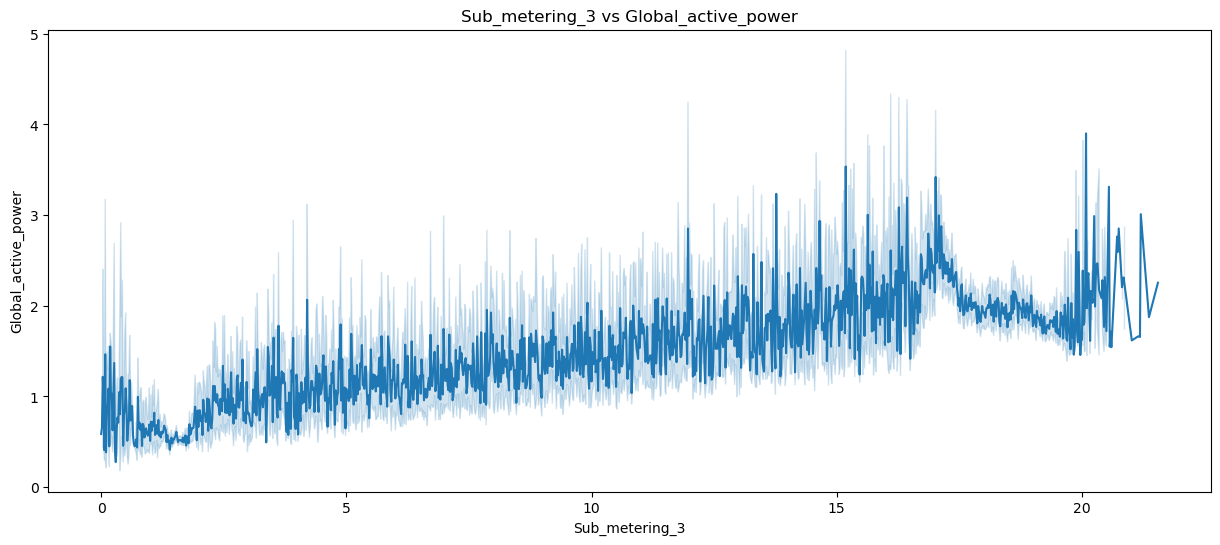

In [26]:
plt.figure(figsize=(15, 6))
sns.lineplot(x='Sub_metering_3', y='Global_active_power', data=hourly_data)
plt.title('Sub_metering_3 vs Global_active_power')
plt.show()

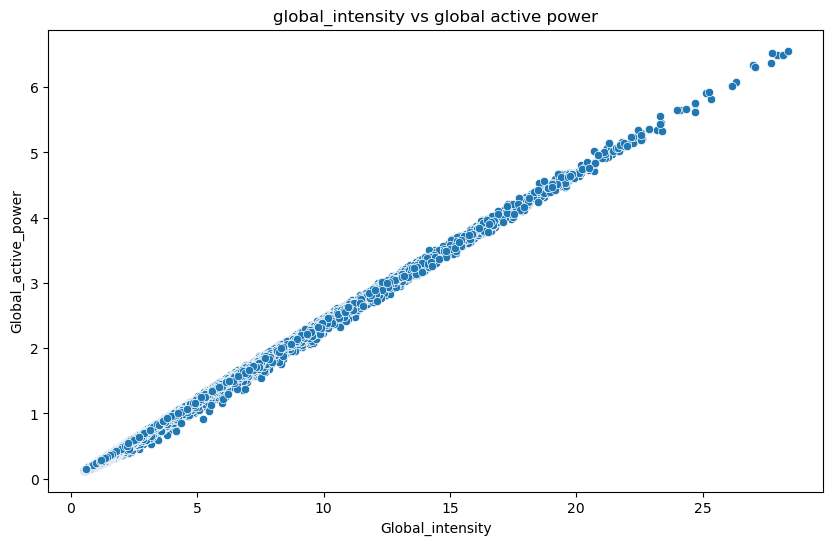

In [27]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Global_intensity', y='Global_active_power', data=hourly_data)
plt.title('global_intensity vs global active power')
plt.show()

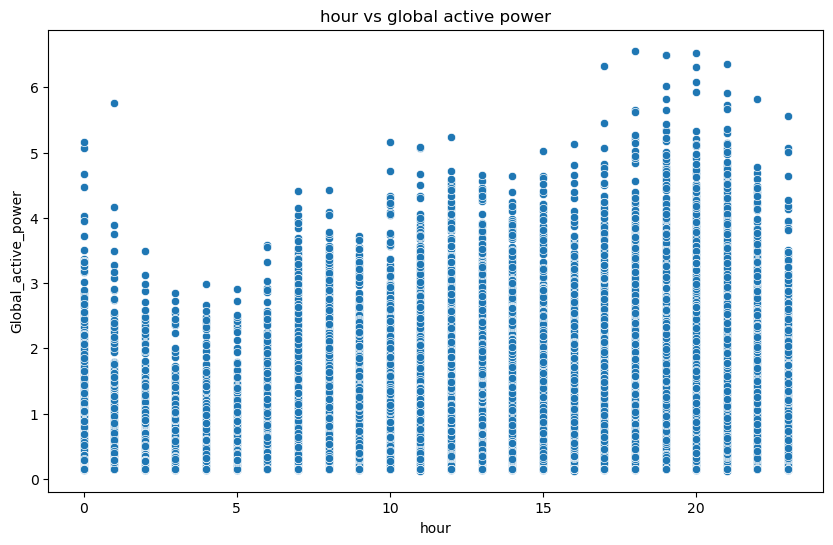

In [28]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='hour', y='Global_active_power', data=hourly_data)
plt.title('hour vs global active power')
plt.show()

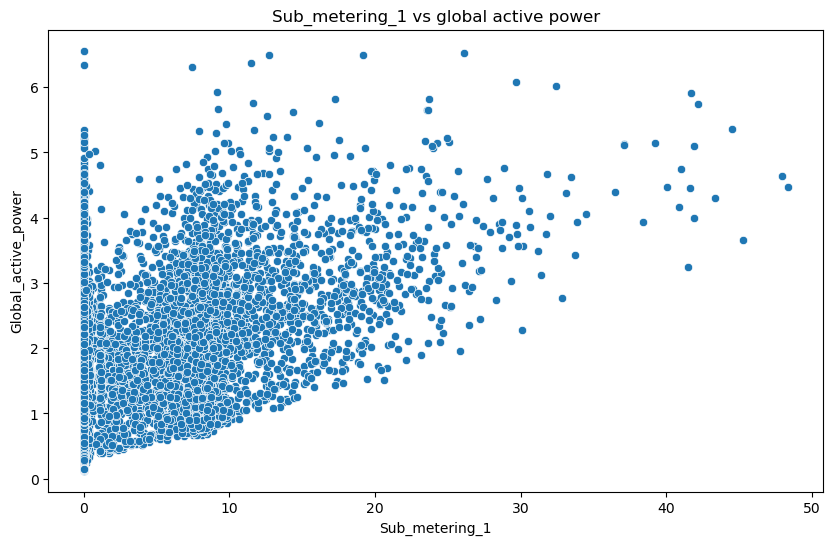

In [29]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Sub_metering_1', y='Global_active_power', data=hourly_data)
plt.title('Sub_metering_1 vs global active power')
plt.show()

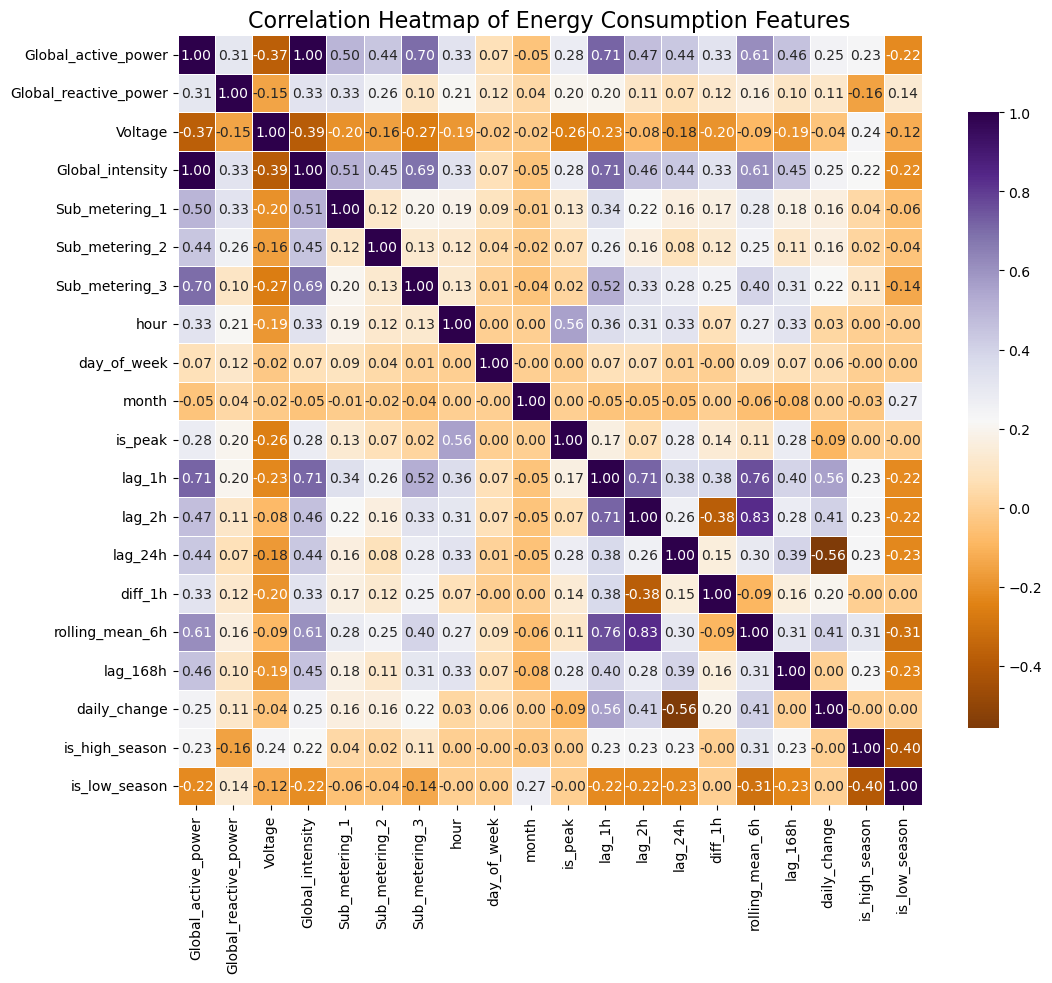

In [30]:
plt.figure(figsize=(12, 10))

# Calculate correlation
corr_matrix = hourly_data.corr()

# Create the heatmap with improved formatting
sns.heatmap(corr_matrix, 
            annot=True,      # Show the numeric values
            fmt=".2f",       # Format to 2 decimal places
            cmap='PuOr',     # Color map from your screenshot
            linewidths=0.5,  # Add lines between squares
            cbar_kws={"shrink": .8}) # Adjust color bar size

plt.title('Correlation Heatmap of Energy Consumption Features', fontsize=16)
plt.xticks(rotation=90) # Rotate labels for better fit
plt.show()

In [31]:
from sklearn.model_selection import train_test_split

# 1. Define the Target (y) and Features (X)
target_col = 'Global_active_power'

# DROPPING "LEAKY" FEATURES: 
# We remove all sensors (Intensity, Voltage, Sub-metering) 
# so the model must forecast using ONLY time patterns.
leaky_features = [
    
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3',
    
]

X = hourly_data.drop(columns=[target_col] + leaky_features)
y = hourly_data[target_col]
print(X.shape[1]) # This tells you how many columns the AI is actually looking at
print("Features being used for forecasting:", X.columns.tolist())

# 2. Chronological Split (Keep this exactly as you had it)
split_index = int(len(hourly_data) * 0.8)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# 3. Data Scaling (Keep this exactly as you had it)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

13
Features being used for forecasting: ['hour', 'day_of_week', 'month', 'is_peak', 'lag_1h', 'lag_2h', 'lag_24h', 'diff_1h', 'rolling_mean_6h', 'lag_168h', 'daily_change', 'is_high_season', 'is_low_season']


In [40]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
import numpy as np

# 1. Initialize the Models
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
lr_model = LinearRegression()

# 2. Train the Models
print("Training models on forecasting features...")
rf_model.fit(X_train_scaled, y_train)
xgb_model.fit(X_train_scaled, y_train)
lr_model.fit(X_train_scaled, y_train)

# 3. Make Predictions
rf_preds = rf_model.predict(X_test_scaled)
xgb_preds = xgb_model.predict(X_test_scaled)
lr_preds = lr_model.predict(X_test_scaled)

# 4. Calculate Metrics
def get_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results = [
    get_metrics(y_test,lr_preds,'linear regreesion'),
    get_metrics(y_test, rf_preds, 'Random Forest'),
    get_metrics(y_test, xgb_preds, 'XGBoost'),
    get_metrics(y_test, lgb_preds, 'LGBM'),
   
    
]

# 5. Display Results
df_results = pd.DataFrame(results)
print("\n--- NEW FORECASTING PERFORMANCE ---")
display(df_results)

Training models on forecasting features...

--- NEW FORECASTING PERFORMANCE ---


,Model,MAE,RMSE,R2
0,linear regreesion,0.351637,0.488561,0.552798
1,Random Forest,0.290696,0.427917,0.656928
2,XGBoost,0.291109,0.421789,0.666683
3,LGBM,0.287321,0.418388,0.672038


In [33]:
import lightgbm as lgb
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Create the LightGBM Dataset format
train_data = lgb.Dataset(X_train_scaled, label=y_train)
test_data = lgb.Dataset(X_test_scaled, label=y_test, reference=train_data)

# 2. Define Parameters
# These parameters are optimized for accuracy without crashing
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9,
    'random_state': 42,
    'verbosity': -1
}

# 3. Train the Model
print("Training LightGBM...")
lgb_model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[train_data, test_data],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

# 4. Predict and Evaluate
lgb_preds = lgb_model.predict(X_test_scaled, num_iteration=lgb_model.best_iteration)

r2 = r2_score(y_test, lgb_preds)
mae = mean_absolute_error(y_test, lgb_preds)

print(f"\nLightGBM Performance:")
print(f"R2 Score: {r2:.4f}")
print(f"MAE: {mae:.4f}")

Training LightGBM...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[306]	training's rmse: 0.414423	valid_1's rmse: 0.418388

LightGBM Performance:
R2 Score: 0.6720
MAE: 0.2873


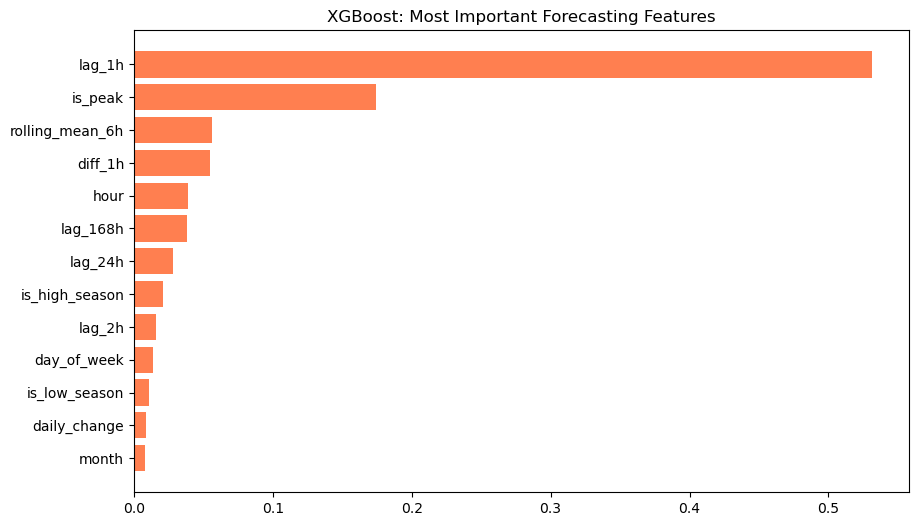

In [34]:
import pandas as pd
import matplotlib.pyplot as plt


importances = xgb_model.feature_importances_
feature_names = X.columns

feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feature_df['Feature'], feature_df['Importance'], color='coral')
plt.title('XGBoost: Most Important Forecasting Features')
plt.show()

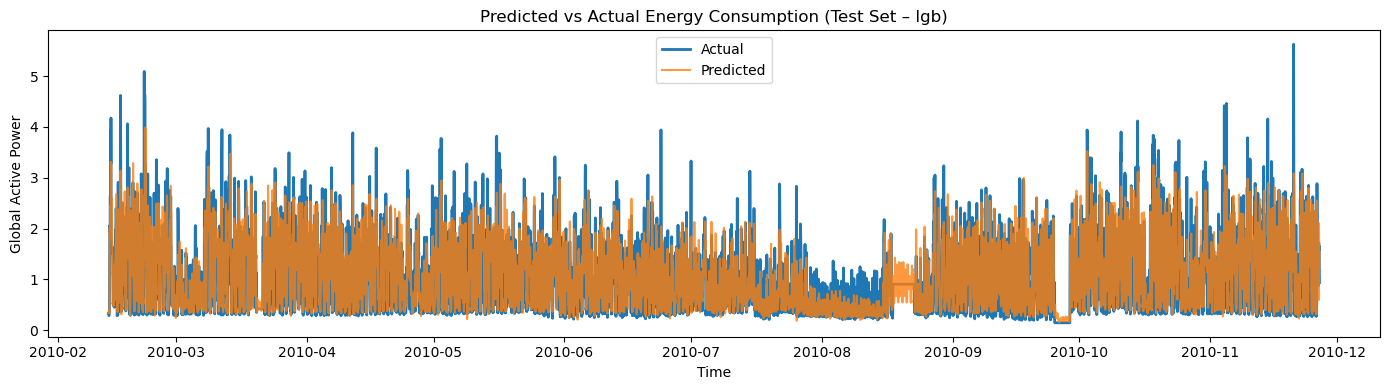

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 4))
plt.plot(y_test.index, y_test, label="Actual", linewidth=2)
plt.plot(y_test.index, lgb_preds , label="Predicted", alpha=0.8)

plt.title("Predicted vs Actual Energy Consumption (Test Set – lgb)")
plt.xlabel("Time")
plt.ylabel("Global Active Power")
plt.legend()
plt.tight_layout()
plt.show()
